In [32]:
!pip install -q numpy scikit-learn matplotlib requests python-dotenv

In [33]:
from google.colab import userdata
import requests

In [34]:
import math
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [35]:
API_KEY = userdata.get("OPENROUTER_API_KEY")

if not API_KEY:
    raise ValueError(
        "OPENROUTER_API_KEY was not found. "
        "Add it to Colab's secrets (key icon in the sidebar) before continuing."
    )

In [36]:
response = requests.post(
    "https://openrouter.ai/api/v1/embeddings",
    headers={
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    },
    json={
        "model": "openai/text-embedding-3-small",
        "input": "The quick brown fox jumps over the lazy dog",
    },
)

# Fail fast with a clear error instead of a confusing KeyError later
# if the API call itself did not succeed.
response.raise_for_status()

In [37]:
data = response.json()
embedding = data["data"][0]["embedding"]
print(f"Embedding dimension: {len(embedding)}")

Embedding dimension: 1536


In [18]:
data

{'object': 'list',
 'data': [{'object': 'embedding',
   'embedding': [-0.020843505859375,
    -0.0168914794921875,
    -0.00450897216796875,
    -0.050872802734375,
    -0.0259552001953125,
    0.0296173095703125,
    0.0299530029296875,
    0.0290985107421875,
    0.010589599609375,
    -0.0243682861328125,
    -0.009368896484375,
    0.00659942626953125,
    -0.0260467529296875,
    0.034820556640625,
    -0.0165557861328125,
    0.00021982192993164062,
    -0.009674072265625,
    -0.055572509765625,
    -0.037933349609375,
    -0.024017333984375,
    -0.0214080810546875,
    0.0030460357666015625,
    0.01102447509765625,
    -0.0048980712890625,
    -0.0007147789001464844,
    -0.0023860931396484375,
    0.0113983154296875,
    -0.03155517578125,
    0.01078033447265625,
    -0.0010833740234375,
    0.0298919677734375,
    -0.0311126708984375,
    -0.0104217529296875,
    -0.061370849609375,
    -0.01499176025390625,
    -0.03729248046875,
    -0.0293731689453125,
    -0.0111618041

### 1. Euclidean Distance

In [ ]:
def euclidean_distance(embedding_a: list[float], embedding_b: list[float]) -> float:
    """Compute the Euclidean distance between two embedding vectors.

    Args:
        embedding_a: First embedding vector.
        embedding_b: Second embedding vector.

    Returns:
        The Euclidean distance between the two vectors.

    Raises:
        ValueError: If the vectors have different dimensions.
    """
    if len(embedding_a) != len(embedding_b):
        raise ValueError("Embeddings must have the same dimension.")

    squared_diff_sum = sum((a - b) ** 2 for a, b in zip(embedding_a, embedding_b))

    return math.sqrt(squared_diff_sum)

### 2. Cosine Distance

In [ ]:
def cosine_distance(embedding_a: list[float], embedding_b: list[float]) -> float:
    """Compute the cosine distance (1 - cosine similarity) between two vectors.

    Args:
        embedding_a: First embedding vector.
        embedding_b: Second embedding vector.

    Returns:
        The cosine distance between the two vectors (0 = identical direction,
        1 = orthogonal, 2 = opposite direction).

    Raises:
        ValueError: If the vectors have different dimensions, or if either
            vector has zero magnitude (cosine similarity is undefined for a
            null vector).
    """
    if len(embedding_a) != len(embedding_b):
        raise ValueError("Embeddings must have the same dimension.")

    dot_product = sum(a * b for a, b in zip(embedding_a, embedding_b))
    norm_a = math.sqrt(sum(a ** 2 for a in embedding_a))
    norm_b = math.sqrt(sum(b ** 2 for b in embedding_b))

    if norm_a == 0 or norm_b == 0:
        raise ValueError("Cannot compute cosine distance with a null vector.")

    cosine_similarity = dot_product / (norm_a * norm_b)

    return 1 - cosine_similarity

### 3. Testing the Functions

In [ ]:
embedding_a = [1, 0, 0]
embedding_b = [0, 1, 0]
embedding_c = [1, 0, 0]

print("A -> B")
print("Euclidean:", euclidean_distance(embedding_a, embedding_b))
print("Cosine:", cosine_distance(embedding_a, embedding_b))

print("\nA -> C")
print("Euclidean:", euclidean_distance(embedding_a, embedding_c))
print("Cosine:", cosine_distance(embedding_a, embedding_c))

print("\nB -> C")
print("Euclidean:", euclidean_distance(embedding_b, embedding_c))
print("Cosine:", cosine_distance(embedding_b, embedding_c))

A -> B
Euclidean: 1.4142135623730951
Cosine: 1.0

A -> C
Euclidean: 0.0
Cosine: 0.0

B -> C
Euclidean: 1.4142135623730951
Cosine: 1.0


### 4. Applying to the Terms from Class

In [ ]:
embedding_cat = [1.0, 0.9, 0.1]
embedding_feline = [0.9, 1.0, 0.1]
embedding_dog = [0.8, 0.7, 0.2]

embedding_car = [0.1, 0.2, 1.0]
embedding_truck = [0.1, 0.3, 0.9]
embedding_motorcycle = [0.2, 0.3, 0.8]

embedding_banana = [0.7, 0.1, 0.2]
embedding_apple = [0.6, 0.2, 0.2]
embedding_guava = [0.5, 0.2, 0.3]

In [ ]:
print("Cat x Feline")
print("Euclidean:", euclidean_distance(embedding_cat, embedding_feline))
print("Cosine:", cosine_distance(embedding_cat, embedding_feline))

print("\nCar x Truck")
print("Euclidean:", euclidean_distance(embedding_car, embedding_truck))
print("Cosine:", cosine_distance(embedding_car, embedding_truck))

print("\nBanana x Apple")
print("Euclidean:", euclidean_distance(embedding_banana, embedding_apple))
print("Cosine:", cosine_distance(embedding_banana, embedding_apple))

Cat x Feline
Euclidean: 0.14142135623730948
Cosine: 0.005494505494505586

Car x Truck
Euclidean: 0.14142135623730948
Cosine: 0.007669388831071711

Banana x Apple
Euclidean: 0.1414213562373095
Cosine: 0.015268072165337987


### 5. Real Embeddings and 3D Visualization

The previous section used hand-picked vectors to illustrate the metrics.
Here we fetch **real embeddings** from the API for a set of related terms,
reduce them from 1536 dimensions to 3 with PCA, and plot them in 3D to see
how semantically related terms cluster together.

In [ ]:
def fetch_embeddings(texts: list[str]) -> tuple[list[list[float]], int]:
    """Fetch embeddings for a batch of texts from the OpenRouter API.

    Args:
        texts: List of strings to embed.

    Returns:
        A tuple of (embeddings, tokens_used):
            - embeddings: one vector per input text, in the same order as
              `texts`.
            - tokens_used: total tokens billed for this request, as
              reported by the API's `usage` field.

    Raises:
        requests.HTTPError: If the API request fails.
    """
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": "openai/text-embedding-3-small",
            "input": texts,
        },
    )
    response.raise_for_status()

    payload = response.json()
    # The API preserves input order via the "index" field, so we sort on it
    # defensively instead of assuming the response order matches the request.
    sorted_items = sorted(payload["data"], key=lambda item: item["index"])
    embeddings = [item["embedding"] for item in sorted_items]
    tokens_used = payload.get("usage", {}).get("total_tokens", 0)

    return embeddings, tokens_used

In [ ]:
terms_by_category = {
    "animal": ["cat", "feline", "dog"],
    "vehicle": ["car", "truck", "motorcycle"],
    "fruit": ["banana", "apple", "guava"],
}

terms = [term for group in terms_by_category.values() for term in group]
categories = [
    category
    for category, group in terms_by_category.items()
    for _ in group
]

In [ ]:
real_embeddings, _ = fetch_embeddings(terms)
embeddings_matrix = np.array(real_embeddings)

print(f"Fetched {embeddings_matrix.shape[0]} embeddings "
      f"of dimension {embeddings_matrix.shape[1]}")

Fetched 9 embeddings of dimension 1536


In [ ]:
pca = PCA(n_components=3, random_state=42)
embeddings_3d = pca.fit_transform(embeddings_matrix)

explained_variance = pca.explained_variance_ratio_.sum()
print(f"Variance explained by the first 3 components: {explained_variance:.1%}")

Variance explained by the first 3 components: 55.2%


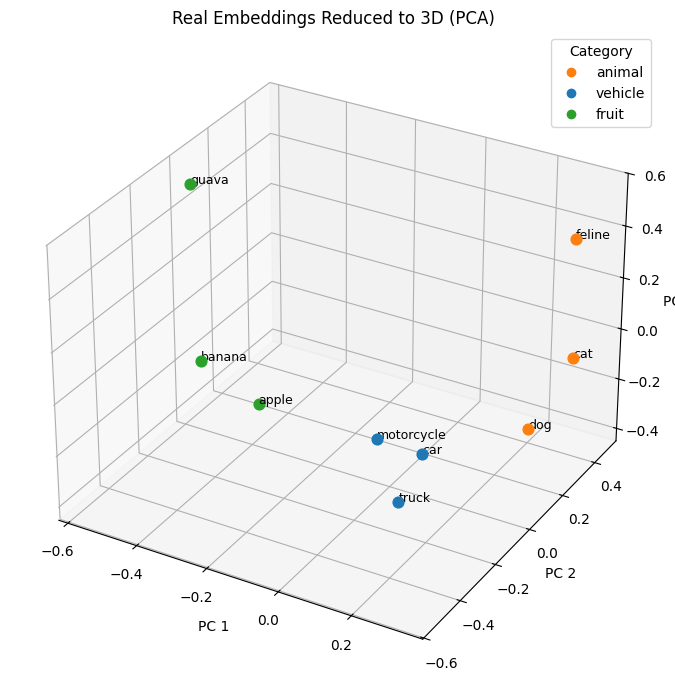

In [ ]:
category_colors = {
    "animal": "tab:orange",
    "vehicle": "tab:blue",
    "fruit": "tab:green",
}

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for term, category, (x, y, z) in zip(terms, categories, embeddings_3d):
    ax.scatter(x, y, z, color=category_colors[category], s=60)
    ax.text(x, y, z, term, fontsize=9)

# One legend entry per category instead of one per point
legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=category)
    for category, color in category_colors.items()
]
ax.legend(handles=legend_handles, title="Category")

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title("Real Embeddings Reduced to 3D (PCA)")

plt.tight_layout()
plt.show()

# Challenge — Manual Semantic Search

Compares three chunking strategies (line, paragraph, chapter) for the
Markdown files produced in Aula 02, using cosine similarity between the
query embedding and each chunk's embedding to retrieve the top 3 most
relevant chunks per strategy.

> **Note on language:** identifiers, comments, and log messages below are
> in English, per the project's standard. The actual search queries, the
> compared sentences, and the source documents remain in Portuguese -
> translating them would change what is being embedded and compared,
> altering the exercise's behavior and results.

In [9]:
import pandas as pd
from IPython.display import display

### 1. Distance and Similarity Functions (NumPy)

These mirror `euclidean_distance()` / `cosine_distance()` from Part 1, but
operate on NumPy arrays instead of plain Python lists. This makes them
efficient for the hundreds of 1536-dimensional embeddings used in the
search below, where a pure-Python loop would be noticeably slower.

They are also intentionally more permissive with a null vector — instead
of raising, `cosine_similarity_np()` returns `0.0` (minimum similarity),
so that a single degenerate embedding doesn't crash a batch search over
many chunks.

In [10]:
def euclidean_distance_np(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
    """Compute the Euclidean distance between two vectors using NumPy."""
    return float(np.linalg.norm(vector_a - vector_b))


def cosine_similarity_np(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
    """Compute the cosine similarity between two vectors using NumPy.

    Returns 0.0 if either vector has zero magnitude, since cosine
    similarity is undefined in that case.
    """
    norm_a = np.linalg.norm(vector_a)
    norm_b = np.linalg.norm(vector_b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(vector_a, vector_b) / (norm_a * norm_b))


def cosine_distance_np(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
    """Compute the cosine distance (1 - cosine similarity) using NumPy."""
    return float(1.0 - cosine_similarity_np(vector_a, vector_b))

### 2. Quick Validation with Simple Vectors

In [11]:
vector_a = np.array([1, 0, 0])
vector_b = np.array([0, 1, 0])
vector_c = np.array([1, 0, 0])

pairs = [
    ("a vs b", vector_a, vector_b),
    ("a vs c", vector_a, vector_c),
    ("b vs c", vector_b, vector_c),
]

for label, v1, v2 in pairs:
    print(f"{label} -> euclidean: {euclidean_distance_np(v1, v2):.4f} | "
          f"cosine: {cosine_distance_np(v1, v2):.4f}")

a vs b -> euclidean: 1.4142 | cosine: 1.0000
a vs c -> euclidean: 0.0000 | cosine: 0.0000
b vs c -> euclidean: 1.4142 | cosine: 1.0000


### 3. Embedding Helpers (Single + Batched, with Token Tracking)

Both helpers are built on top of `fetch_embeddings()` from Part 1, instead
of duplicating the API-calling logic — see analysis notes for why this
was necessary (the notebook originally called two functions,
`gerar_embedding()` and `gerar_embeddings_em_lote()`, that were never
defined).

In [12]:
def get_single_embedding(text: str) -> list[float]:
    """Fetch the embedding vector for a single piece of text."""
    embeddings, _ = fetch_embeddings([text])
    return embeddings[0]


def generate_embeddings_in_batches(
    texts: list[str], batch_size: int = 50
) -> tuple[list[list[float]], int]:
    """Fetch embeddings for many texts, sending them in fixed-size batches.

    Batching avoids exceeding the API's per-request size limits when
    embedding a large number of chunks.

    Args:
        texts: Texts to embed.
        batch_size: Maximum number of texts sent per API call.

    Returns:
        A tuple of (embeddings, total_tokens_used).
    """
    all_embeddings: list[list[float]] = []
    total_tokens = 0

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        batch_embeddings, batch_tokens = fetch_embeddings(batch)
        all_embeddings.extend(batch_embeddings)
        total_tokens += batch_tokens
        print(f"Batch {start}-{start + len(batch)} processed "
              f"({len(all_embeddings)}/{len(texts)})")

    return all_embeddings, total_tokens

### 4. Real Embeddings for the Class Terms

Same terms specified in the assignment, kept in Portuguese since they are
the actual data being embedded and compared.

In [31]:
words = ["cat", "feline", "dog", "car", "truck", "motorcycle", "banana", "apple", "guava"]
word_embeddings, _ = generate_embeddings_in_batches(words)
word_embeddings = [np.array(e) for e in word_embeddings]

# Example: compare 'cat' against every other word
cat_index = words.index("cat")
cat_vector = word_embeddings[cat_index]

for i, word in enumerate(words):
    if word == "cat":
        continue
    vector = word_embeddings[i]
    print(f"gato vs {word:10s} -> euclidean: {euclidean_distance_np(cat_vector, vector):.4f} | "
          f"cosine: {cosine_distance_np(cat_vector, vector):.4f}")

Batch 0-9 processed (9/9)
gato vs feline     -> euclidean: 0.8405 | cosine: 0.3531
gato vs dog        -> euclidean: 0.8916 | cosine: 0.3973
gato vs car        -> euclidean: 0.9843 | cosine: 0.4841
gato vs truck      -> euclidean: 1.0654 | cosine: 0.5673
gato vs motorcycle -> euclidean: 1.1605 | cosine: 0.6730
gato vs banana     -> euclidean: 1.1853 | cosine: 0.7021
gato vs apple      -> euclidean: 1.1345 | cosine: 0.6431
gato vs guava      -> euclidean: 1.2504 | cosine: 0.7811


### 5. Sentence Similarity Example

In [48]:
anchor_sentence = "The dog ran in the park and played with the ball."

comparison_sentences = [
    ("Similar (same meaning, different words)", "A dog was running in the garden and playing with its toy."),
    ("Related (same domain - animals)", "The cat slept on the living room cushion all afternoon."),
    ("Different (another domain - economy)", "The central bank's interest rate rose by two percentage points."),
    ("Opposite/Negation", "No animal was in the park, and the dog remained confined at home."),
]

anchor_vector = np.array(get_single_embedding(anchor_sentence), dtype=np.float32)

comparison_results = []
for label, sentence in comparison_sentences:
    vector = np.array(get_single_embedding(sentence), dtype=np.float32)
    comparison_results.append({
        "Text": label,
        "Euclidean Distance": round(euclidean_distance_np(anchor_vector, vector), 4),
        "Cosine Similarity": round(cosine_similarity_np(anchor_vector, vector), 4),
        "Cosine Distance": round(cosine_distance_np(anchor_vector, vector), 4),
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Text,Euclidean Distance,Cosine Similarity,Cosine Distance
0,"Similar (same meaning, different words)",0.8129,0.6697,0.3303
1,Related (same domain - animals),1.1940,0.2874,0.7126
2,Different (another domain - economy),1.3539,0.0837,0.9163
3,Opposite/Negation,1.0002,0.4999,0.5001


### 6. Upload the Class Documents

Upload the Markdown files generated in Aula 02 (`.md` files converted
from the source PDFs).

In [49]:
from google.colab import files

uploaded = files.upload()

Saving bioetica_e_ia.md to bioetica_e_ia.md
Saving escrita_academica_ia.md to escrita_academica_ia.md
Saving twitter_algoritmo.md to twitter_algoritmo.md


In [50]:
import os

print(os.listdir("/content"))

['.config', 'twitter_algoritmo.md', 'bioetica_e_ia.md', 'escrita_academica_ia.md', 'sample_data']


### 7. Chunking Strategy — Line

In [51]:
md_files = ["twitter_algoritmo.md", "escrita_academica_ia.md", "bioetica_e_ia.md"]

line_chunks = []  # each item: {"text": ..., "file": ...}

for file_name in md_files:
    with open(file_name, "r", encoding="utf-8") as f:
        lines = f.readlines()
    for line in lines:
        clean_line = line.strip()
        if clean_line:  # skip empty lines
            line_chunks.append({"text": clean_line, "file": file_name})

print(f"Total non-empty lines read: {len(line_chunks)}")
print("\nExample chunk:")
print(line_chunks[0])

Total non-empty lines read: 205

Example chunk:
{'text': 'ARTIGOS                                                            E-ISSN: 2176-6665', 'file': 'twitter_algoritmo.md'}


In [52]:
line_texts = [chunk["text"] for chunk in line_chunks]
line_embeddings, line_tokens = generate_embeddings_in_batches(line_texts, batch_size=50)

print(f"\n✅ Total embeddings generated: {len(line_embeddings)}")
print(f"Total tokens spent: {line_tokens}")

Batch 0-50 processed (50/205)
Batch 50-100 processed (100/205)
Batch 100-150 processed (150/205)
Batch 150-200 processed (200/205)
Batch 200-205 processed (205/205)

✅ Total embeddings generated: 205
Total tokens spent: 22640


In [53]:
def search_top_k(
    query: str,
    chunks: list[dict],
    chunk_embeddings: list[list[float]],
    k: int = 3,
) -> list[dict]:
    """Simple semantic search: compare the query embedding against every
    chunk embedding and return the top k most similar chunks.

    Args:
        query: Natural-language search query.
        chunks: List of {"text": ..., "file": ...} dictionaries.
        chunk_embeddings: Embedding vector for each chunk, in the same
            order as `chunks`.
        k: Number of top results to return.

    Returns:
        The top k chunks, each annotated with its cosine similarity score,
        sorted from most to least similar.
    """
    query_vector = np.array(get_single_embedding(query), dtype=np.float32)

    results = []
    for chunk, embedding in zip(chunks, chunk_embeddings):
        chunk_vector = np.array(embedding, dtype=np.float32)
        score = cosine_similarity_np(query_vector, chunk_vector)
        results.append({
            "score": round(score, 4),
            "text": chunk["text"],
            "file": chunk["file"],
        })

    results.sort(key=lambda item: item["score"], reverse=True)
    return results[:k]

# Example search
query = "O que é bioética e por que ela é importante na inteligência artificial?"
top3_lines = search_top_k(query, line_chunks, line_embeddings, k=3)

top3_lines_df = pd.DataFrame(top3_lines)
top3_lines_df

,score,text,file
0,0.6880,O descompasso entre a velocidade da ino ...,bioetica_e_ia.md
1,0.6827,Palavras-chave: Bioética. Inteligência artific...,bioetica_e_ia.md
2,0.6819,O avanço da inteligência artificial tem transf...,bioetica_e_ia.md


### 8. Chunking Strategy — Paragraph

In [54]:
def read_paragraphs(file_name: str, min_chars: int = 80) -> list[str]:
    """Split a Markdown file into paragraphs (blocks separated by a blank line).

    Blocks shorter than `min_chars` are discarded, to filter out page
    numbers, image markers, and standalone titles.
    """
    with open(file_name, "r", encoding="utf-8") as f:
        content = f.read()
    blocks = content.split("\n\n")
    return [b.strip() for b in blocks if len(b.strip()) >= min_chars]


paragraph_chunks = []
for file_name in md_files:
    for paragraph in read_paragraphs(file_name):
        paragraph_chunks.append({"text": paragraph, "file": file_name})

print(f"Total paragraphs read: {len(paragraph_chunks)}")
print("\nExample paragraph:")
print(paragraph_chunks[0]["text"][:300], "...")

Total paragraphs read: 143

Example paragraph:
ARTIGOS                                                            E-ISSN: 2176-6665 ...


In [55]:
paragraph_texts = [chunk["text"] for chunk in paragraph_chunks]
paragraph_embeddings, paragraph_tokens = generate_embeddings_in_batches(paragraph_texts, batch_size=50)

print(f"\n✅ Total embeddings generated: {len(paragraph_embeddings)}")
print(f"Total tokens spent: {paragraph_tokens}")

Batch 0-50 processed (50/143)
Batch 50-100 processed (100/143)
Batch 100-143 processed (143/143)

✅ Total embeddings generated: 143
Total tokens spent: 22059


In [56]:
# Repeat the search with the same query, now by paragraph
top3_paragraphs = search_top_k(query, paragraph_chunks, paragraph_embeddings, k=3)

top3_paragraphs_df = pd.DataFrame(top3_paragraphs)
top3_paragraphs_df

,score,text,file
0,0.6880,O descompasso entre a velocidade da ino ...,bioetica_e_ia.md
1,0.6827,Palavras-chave: Bioética. Inteligência artific...,bioetica_e_ia.md
2,0.6819,O avanço da inteligência artificial tem transf...,bioetica_e_ia.md


In [62]:
# Test with a query aimed at the body text (not metadata)
query_2 = "How can artificial intelligence help with medical diagnosis?"

print("=== Search by LINE ===")
display(pd.DataFrame(search_top_k(query_2, line_chunks, line_embeddings, k=3)))

print("\n=== Search by PARAGRAPH ===")
display(pd.DataFrame(search_top_k(query_2, paragraph_chunks, paragraph_embeddings, k=3)))

=== Search by LINE ===


,score,text,file
0,0.6202,A introdução da inteligência artificial (IA) n...,bioetica_e_ia.md
1,0.6095,The advancement of artificial intelligence has...,bioetica_e_ia.md
2,0.5784,"A beneficência, enquanto obrigação moral d...",bioetica_e_ia.md



=== Search by PARAGRAPH ===


,score,text,file
0,0.6201,A introdução da inteligência artificial (IA) n...,bioetica_e_ia.md
1,0.6095,The advancement of artificial intelligence has...,bioetica_e_ia.md
2,0.5779,"A beneficência, enquanto obrigação moral d...",bioetica_e_ia.md


### 9. Chunking Strategy — Chapter

Sections are marked by `##` headings in the Markdown files.

In [64]:
import re


def read_chapters(file_name: str, min_chars: int = 100) -> list[str]:
    """Split a Markdown file into chapters/sections, marked by `## ` headings.

    Sections shorter than `min_chars` are discarded (empty or near-empty
    sections).
    """
    with open(file_name, "r", encoding="utf-8") as f:
        content = f.read()
    parts = re.split(r"\n##\s+", content)
    return [p.strip() for p in parts if len(p.strip()) >= min_chars]


chapter_chunks = []
for file_name in md_files:
    for chapter in read_chapters(file_name):
        chapter_chunks.append({"text": chapter, "file": file_name})

print(f"Total chapters/sections read: {len(chapter_chunks)}")
print("\nExample chapter (first 300 characters):")
print(chapter_chunks[0]["text"][:300], "...")

Total chapters/sections read: 28

Example chapter (first 300 characters):
DOI: 10.5433/2176-6665.2025v30e52669

Recebido em 30/03/2025; aprovado em 18/096/2025; publicado em 10/11/2025. ...


In [65]:
chapter_texts = [chunk["text"] for chunk in chapter_chunks]
chapter_embeddings, chapter_tokens = generate_embeddings_in_batches(chapter_texts, batch_size=50)

print(f"\n✅ Total embeddings generated: {len(chapter_embeddings)}")
print(f"Total tokens spent: {chapter_tokens}")

Batch 0-28 processed (28/28)

✅ Total embeddings generated: 28
Total tokens spent: 22607


### 10. Comparing All Three Strategies

In [66]:
print("=== Search by LINE ===")
display(pd.DataFrame(search_top_k(query_2, line_chunks, line_embeddings, k=3)))

print("\n=== Search by PARAGRAPH ===")
display(pd.DataFrame(search_top_k(query_2, paragraph_chunks, paragraph_embeddings, k=3)))

print("\n=== Search by CHAPTER ===")
top3_chapters_q2 = search_top_k(query_2, chapter_chunks, chapter_embeddings, k=3)
for result in top3_chapters_q2:
    print(f"\nScore: {result['score']} | File: {result['file']}")
    print(f"Text: {result['text'][:400]}...")

=== Search by LINE ===


,score,text,file
0,0.6201,A introdução da inteligência artificial (IA) n...,bioetica_e_ia.md
1,0.6095,The advancement of artificial intelligence has...,bioetica_e_ia.md
2,0.5784,"A beneficência, enquanto obrigação moral d...",bioetica_e_ia.md



=== Search by PARAGRAPH ===


,score,text,file
0,0.6201,A introdução da inteligência artificial (IA) n...,bioetica_e_ia.md
1,0.6095,The advancement of artificial intelligence has...,bioetica_e_ia.md
2,0.5779,"A beneficência, enquanto obrigação moral d...",bioetica_e_ia.md



=== Search by CHAPTER ===

Score: 0.4794 | File: bioetica_e_ia.md
Text: Resumo

O avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoces, terapias personalizadas, otimização de recursos, redução de erros e ampliação do acesso a cuidados especializados. Contudo, essa revolução tecnológ...

Score: 0.4651 | File: bioetica_e_ia.md
Text: Entre el algoritmo y el Juramento Hipocrático: bioética en la era de la inteligencia artificial

El avance de la inteligencia artificial ha transformado profundamente la práctica médica. Desde sistemas de apoyo a la decisión clínica hasta algoritmos de triaje y diagnóstico, la inteligencia artificial ha demostrado potencial para diagnósticos precoces, terapias personalizadas, optimización de recur...

Score: 0.4546 | File: bioetica_e_ia.md
Text: Between the algorithm and t

### Diagnostics

Quick look at the raw structure of one of the source files (useful when
tuning the chunking strategies above).

In [67]:
with open("bioetica_e_ia.md", "r", encoding="utf-8") as f:
    content = f.read()

print(repr(content[:500]))

'273\n\n<!-- image -->\n\n## Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial\n\nJuracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1\n\n1. Faculdade de Medicina da Universidade do Porto, Porto, Portugal.\n\n## Resumo\n\nO avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoc'
